# Segmentation walkthrough

1. make some image/mask data
2. turn a mask into a SAM2-style prompt (point or box)
3. build the `DummySegmenter` (stands in for real SAM2) and inject LoRA
4. train with the Dice+BCE loss
5. check Dice / IoU and look at the predictions

> The `DummySegmenter` is a tiny U-Net with the same interface as the real
> `SAM2Segmenter`, so the LoRA + training mechanics are identical and only the
> backbone is swapped out. 

## 0. Setup

In [ ]:
import os, sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

os.environ["PSAI_FORCE_CPU"] = "1"  

import torch
import matplotlib.pyplot as plt

from src.common.device import get_device, device_report

device = get_device()
print(device_report(device))

CPU: everything works but slowly. Fine for the synthetic smoke test only.


## 1. data

In [2]:
from src.segmentation.dataset import SyntheticMaskDataset

train_ds = SyntheticMaskDataset(n=8, img_size=128, seed=0)
val_ds = SyntheticMaskDataset(n=4, img_size=128, seed=1)
print(f"train: {len(train_ds)} samples | val: {len(val_ds)} samples")

sample = train_ds[0]
for k, v in sample.items():
    shape = tuple(v.shape) if torch.is_tensor(v) else v
    print(f"  {k:13s} {shape}")

train: 8 samples | val: 4 samples
  image         (3, 128, 128)
  mask          (1, 128, 128)
  point_coords  (1, 1, 2)
  point_labels  (1, 1)
  box           None


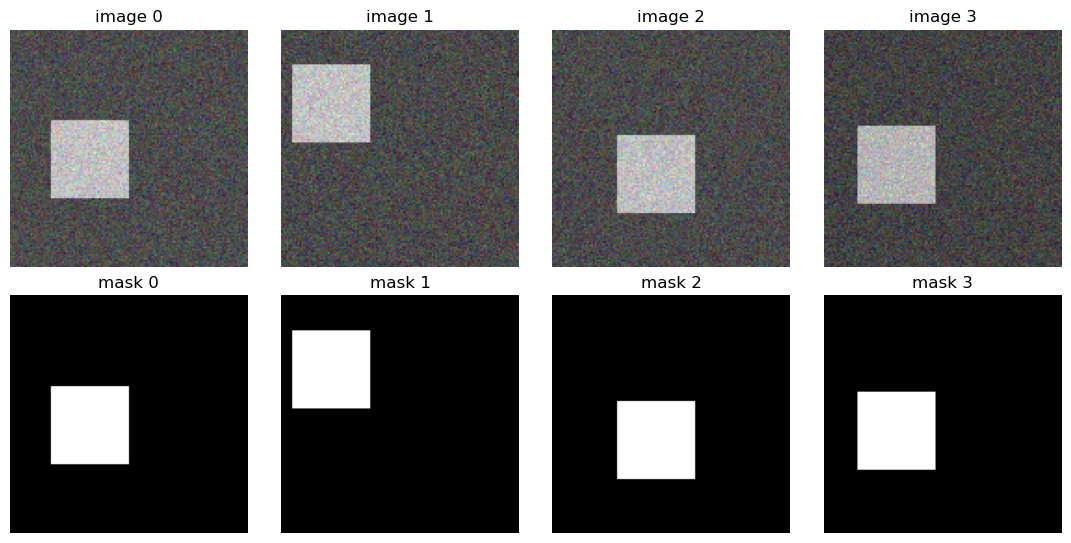

In [3]:
def show_image(ax, img_tensor):
    """img_tensor [3,H,W] -> a plottable [H,W,3] in 0..1."""
    arr = img_tensor.permute(1, 2, 0)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)
    ax.imshow(arr)
    ax.axis("off")

fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
for i in range(4):
    s = train_ds[i]
    show_image(axes[0, i], s["image"])
    axes[0, i].set_title(f"image {i}")
    axes[1, i].imshow(s["mask"][0], cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"mask {i}")
plt.tight_layout()
plt.show()

## 2. Mask -> prompt

point coords: [46.0, 78.0] | label: 1
box (x0,y0,x1,y1): [22.0, 49.0, 63.0, 90.0]


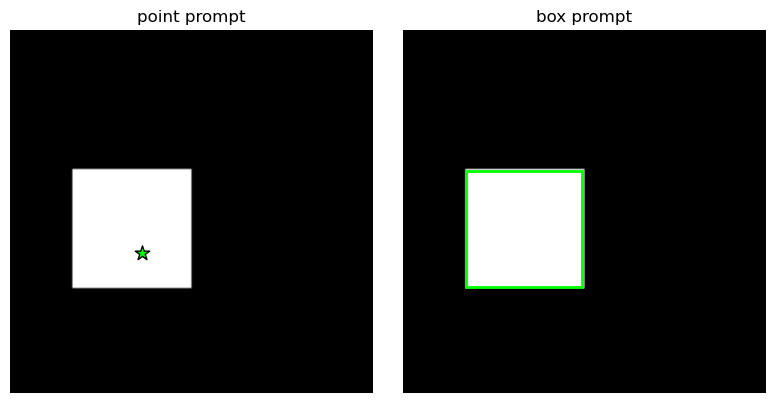

In [4]:
from matplotlib.patches import Rectangle
from src.segmentation.dataset import prompt_from_mask

mask = train_ds[0]["mask"][0]  # [H,W]

pc, pl, _ = prompt_from_mask(mask, kind="point")
_, _, box = prompt_from_mask(mask, kind="box")
print("point coords:", pc.squeeze().tolist(), "| label:", pl.squeeze().tolist())
print("box (x0,y0,x1,y1):", box.squeeze().tolist())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax in axes:
    ax.imshow(mask, cmap="gray")
    ax.axis("off")
px, py = pc.squeeze().tolist()
axes[0].scatter([px], [py], c="lime", s=120, marker="*", edgecolors="black")
axes[0].set_title("point prompt")
x0, y0, x1, y1 = box.squeeze().tolist()
axes[1].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", lw=2))
axes[1].set_title("box prompt")
plt.tight_layout()
plt.show()

## 3. The model + LoRA

In [ ]:
from types import SimpleNamespace
from src.segmentation.sam2_lora import build_segmenter
from src.common.lora import count_trainable

args = SimpleNamespace(synthetic=True, checkpoint=None, lora_rank=4)
model = build_segmenter(args, device)

trainable, total = count_trainable(model)
print(f"\ntrainable {trainable:,} / {total:,} params  ({100*trainable/total:.1f}%)")
print("\nlayers that actually train:")
for name, p in model.named_parameters():
    if p.requires_grad:
        print(f"  {name:30s} {tuple(p.shape)}")

[DummySegmenter] LoRA wrapped 2 linears | trainable 9.8K / 28.8K params

trainable 9,841 / 28,801 params  (34.2%)

layers that actually train:
  fc1.lora_A.weight              (4, 32)
  fc1.lora_B.weight              (32, 4)
  proj.lora_A.weight             (4, 32)
  proj.lora_B.weight             (32, 4)
  dec.net.0.weight               (16, 48, 3, 3)
  dec.net.0.bias                 (16,)
  dec.net.1.weight               (16,)
  dec.net.1.bias                 (16,)
  dec.net.3.weight               (16, 16, 3, 3)
  dec.net.3.bias                 (16,)
  dec.net.4.weight               (16,)
  dec.net.4.bias                 (16,)
  head.weight                    (1, 16, 1, 1)
  head.bias                      (1,)


## 4. One forward pass (before training)

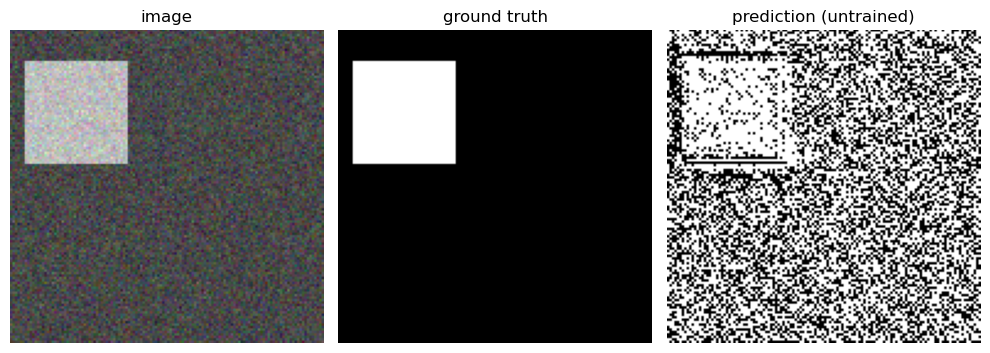

In [6]:
model.eval()
with torch.no_grad():
    img = val_ds[0]["image"].unsqueeze(0).to(device)  # [1,3,H,W]
    logits = model(img)
    pred0 = (logits.sigmoid() > 0.5).float()[0, 0].cpu()

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
show_image(axes[0], val_ds[0]["image"]); axes[0].set_title("image")
axes[1].imshow(val_ds[0]["mask"][0], cmap="gray"); axes[1].set_title("ground truth")
axes[2].imshow(pred0, cmap="gray"); axes[2].set_title("prediction (untrained)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Training

In [7]:
from torch.utils.data import DataLoader
from src.segmentation.sam2_lora import dice_bce_loss
from src.segmentation.train_sam2 import collate, forward_batch

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=collate)
opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3)

max_steps = 40
losses, step = [], 0
model.train()
while step < max_steps:
    for batch in train_loader:
        logits = forward_batch(model, batch, device)
        loss = dice_bce_loss(logits, batch["mask"].to(device))
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        step += 1
        if step % 8 == 0 or step == 1:
            print(f"step {step:02d}/{max_steps} | loss {loss.item():.4f}")
        if step >= max_steps:
            break

step 01/40 | loss 1.4972
step 08/40 | loss 1.0351
step 16/40 | loss 0.8920
step 24/40 | loss 0.8331
step 32/40 | loss 0.7891
step 40/40 | loss 0.7472


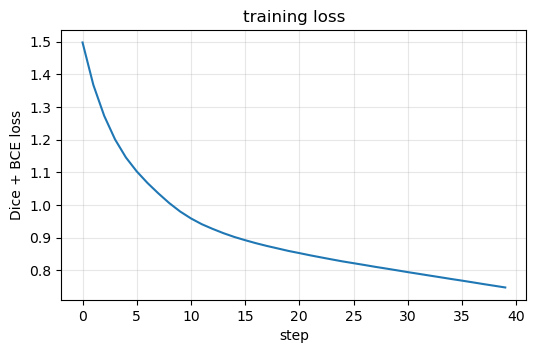

In [8]:
plt.figure(figsize=(6, 3.5))
plt.plot(losses)
plt.xlabel("step"); plt.ylabel("Dice + BCE loss"); plt.title("training loss")
plt.grid(alpha=0.3)
plt.show()

## 6. Evaluate

In [9]:
from src.phase.eval import dice_iou

val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, collate_fn=collate)
model.eval()
dices, ious = [], []
with torch.no_grad():
    for batch in val_loader:
        logits = forward_batch(model, batch, device)
        d, j = dice_iou(logits.cpu(), batch["mask"])
        dices.append(d); ious.append(j)
print(f"val Dice {sum(dices)/len(dices):.3f} | IoU {sum(ious)/len(ious):.3f}")

val Dice 0.981 | IoU 0.962


## 7. Look at the trained predictions

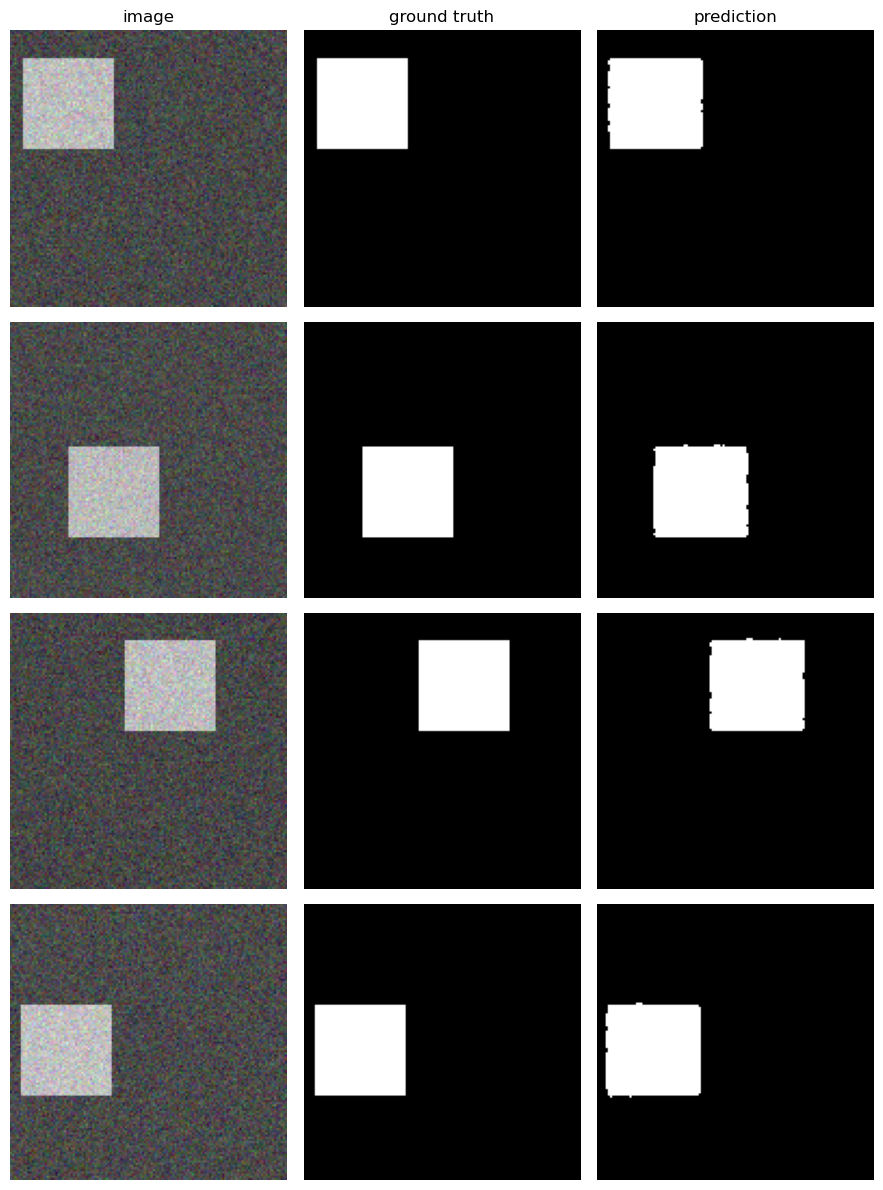

In [10]:
model.eval()
fig, axes = plt.subplots(len(val_ds), 3, figsize=(9, 3 * len(val_ds)))
with torch.no_grad():
    for i in range(len(val_ds)):
        s = val_ds[i]
        logits = model(s["image"].unsqueeze(0).to(device))
        pred = (logits.sigmoid() > 0.5).float()[0, 0].cpu()
        show_image(axes[i, 0], s["image"])
        axes[i, 1].imshow(s["mask"][0], cmap="gray")
        axes[i, 2].imshow(pred, cmap="gray")
        for j, t in enumerate(["image", "ground truth", "prediction"]):
            axes[i, j].axis("off")
            if i == 0:
                axes[i, j].set_title(t)
plt.tight_layout()
plt.show()

## 8. Save the adapters

In [11]:
from src.common.lora import lora_state_dict

os.makedirs("runs/seg", exist_ok=True)
adapters = lora_state_dict(model)
torch.save({"lora": adapters}, "runs/seg/lora_adapters.pt")
print(f"saved {len(adapters)} adapter tensors -> runs/seg/lora_adapters.pt")
for name, t in adapters.items():
    print(f"  {name:30s} {tuple(t.shape)}")

saved 4 adapter tensors -> runs/seg/lora_adapters.pt
  fc1.lora_A.weight              (4, 32)
  fc1.lora_B.weight              (32, 4)
  proj.lora_A.weight             (4, 32)
  proj.lora_B.weight             (32, 4)
